In [1]:
%pip install --quiet -U python-dotenv pydantic-ai ffmpeg-python yt-dlp

import os
from pathlib import Path
import nest_asyncio; nest_asyncio.apply()

# Download data files if not already present (e.g. on Colab)
if not Path("data").exists():
    import zipfile, urllib.request
    url = "https://github.com/jsoma/workshop-ai-images-video/raw/main/docs/nicar-2026/04-video-data.zip"
    print("Downloading data...")
    urllib.request.urlretrieve(url, "_data.zip")
    with zipfile.ZipFile("_data.zip") as zf:
        zf.extractall("data")
    Path("_data.zip").unlink()
    print("Done!")

# Paste API keys here or leave empty for .env / Colab secrets
api_keys = {"OPENAI_API_KEY": "", "GOOGLE_API_KEY": ""}
os.environ.update({k: v for k, v in api_keys.items() if v})
try:
    from google.colab import userdata
    for key in api_keys:
        try: os.environ.setdefault(key, userdata.get(key))
        except Exception: pass
except ImportError:
    from dotenv import load_dotenv; load_dotenv()

DATA = Path("data")
Path("outputs").mkdir(exist_ok=True)


/Users/soma/Library/CloudStorage/Dropbox/Soma/Curriculum/2026-nicar/01-fri-analyzing-images-videos-ai/ai-images-video/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Video

You've got image tools and audio tools. Video is both — frames and a soundtrack — so you already have everything you need! Yes, you could send it to Gemini or another LLM (which we do at the end), but you can also just split it up and reuse what you've learned. Just because public meetings come as videos doesn't mean [you can't just treat them as audio](https://ryanserpi.co/projects/assembly/), and the same way you count or detect objects in images [you can do the same thing in videos](https://www.dw.com/en/betting-ads-swamp-brazilian-football-as-addiction-spikes/a-72941493).

## Download

[yt-dlp](https://github.com/yt-dlp/yt-dlp) is the best tool for downloading video content on the internet. It's gotten less effect at YouTube in the past 6 months or so, but it's still great for older videos and non-YT sites. Always try it out first!


**`video/download.py`** — Download a video from YouTube with yt-dlp


In [ ]:
from pathlib import Path
import yt_dlp

DATA = Path("data")
URL = "https://www.youtube.com/watch?v=rDXubdQdJYs"

DATA.mkdir(parents=True, exist_ok=True)
VIDEO_ID = URL.split("v=")[1]

existing = list(DATA.glob(f"{VIDEO_ID}.*"))
if existing:
    print(f"Already downloaded: {existing[0].name}")
else:
    ydl_opts = {
        "outtmpl": str(DATA / "%(id)s.%(ext)s"),
        "quiet": True,
        "no_warnings": True,
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([URL])
    print(f"Downloaded: {VIDEO_ID}")


Already downloaded: rDXubdQdJYs.mp3


## Extract frames

Since you know how to analyze images, why not just separate out the frames in a video? Below we extract one frame every two seconds. Now you have images: use the image tools!


**`video/frames.py`** — Extract frames from a video at 1 frame every 2 seconds using ffmpeg-python


In [ ]:
import ffmpeg
from pathlib import Path

DATA = Path("data")
VIDEO = DATA / "rDXubdQdJYs.mp4"
OUTPUT = DATA / "debate"
OUTPUT.mkdir(parents=True, exist_ok=True)

(
    ffmpeg
    .input(str(VIDEO))
    .filter("fps", fps=0.5)
    .output(str(OUTPUT / "frame-%03d.jpg"), **{"qscale:v": 2})
    .overwrite_output()
    .run(quiet=True)
)

frames = sorted(OUTPUT.glob("frame-*.jpg"))
print(f"Extracted {len(frames)} frames to {OUTPUT}")


Extracted 30 frames to data/debate


Preview: a sample of what we just extracted.


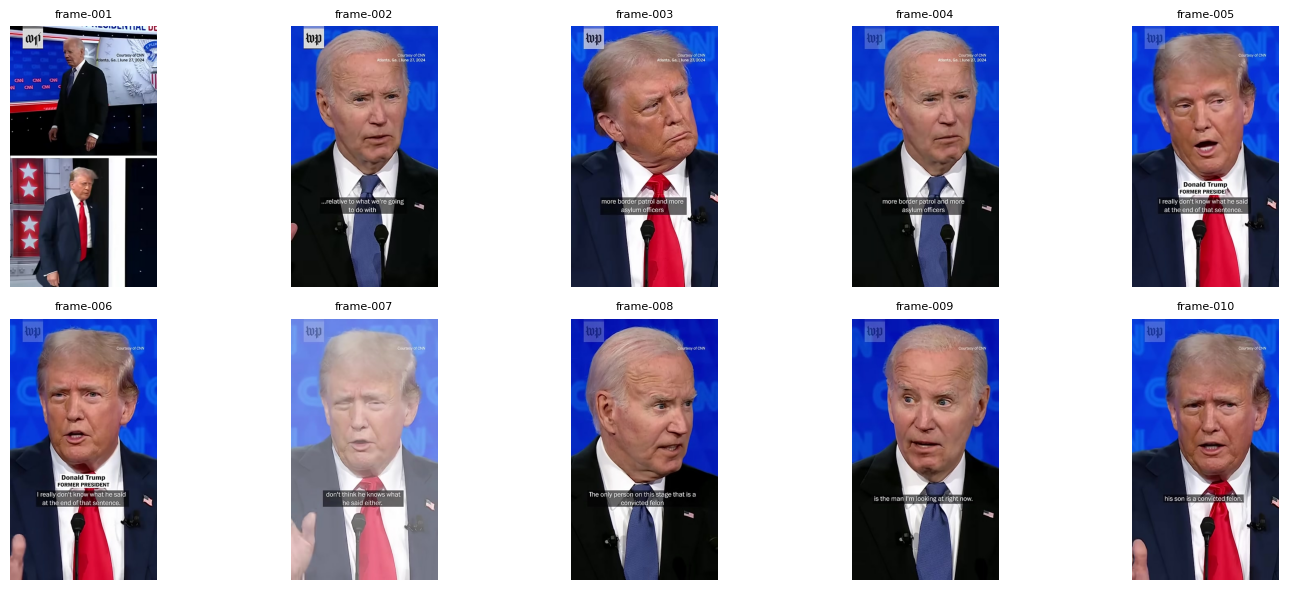

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

sample = frames[:10]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, path in zip(axes.flat, sample):
    ax.imshow(Image.open(path))
    ax.set_title(path.stem, fontsize=8)
    ax.axis("off")
plt.tight_layout()


## Extract audio

Same thing for the audio. Now you have audio: use the audio tools!


**`video/audio.py`** — Extract audio track from a video file using ffmpeg-python


In [ ]:
import ffmpeg
from pathlib import Path

DATA = Path("data")
VIDEO = DATA / "rDXubdQdJYs.mp4"
OUTPUT = Path("outputs")
OUTPUT.mkdir(parents=True, exist_ok=True)

(
    ffmpeg
    .input(str(VIDEO))
    .output(str(OUTPUT / "rDXubdQdJYs.mp3"), acodec="libmp3lame", vn=None)
    .overwrite_output()
    .run(quiet=True)
)

print(f"Audio saved to {OUTPUT / 'rDXubdQdJYs.mp3'}")


Audio saved to outputs/rDXubdQdJYs.mp3


## Answering quetsions the slightly risky way

Just like you can ask AI about images, you can also ask about videos! ...at least, for some of the models. Gemini is probably the best: ask a question about the video, get a confident answer. It... may or may not be accurate.


**`video/vibe-answer.py`** — The risky way: ask Gemini "who got more screen time?" -- confident answer, no evidence


In [ ]:
import time
from pathlib import Path

from pydantic_ai import Agent, VideoUrl
from pydantic_ai.providers.google import GoogleProvider

DATA = Path("data")
VIDEO = DATA / "rDXubdQdJYs.mp4"
MODEL = "google-gla:gemini-2.5-flash"

provider = GoogleProvider()
video_file = provider.client.files.upload(file=str(VIDEO))

while video_file.state.name == "PROCESSING":
    time.sleep(5)
    video_file = provider.client.files.get(name=video_file.name)

agent = Agent(MODEL)
result = agent.run_sync([
    "Who got more screen time in this debate video? "
    "Give me a breakdown of approximately how much time each person was on screen.",
    VideoUrl(url=video_file.uri, media_type=video_file.mime_type),
])

print(result.output)


In this 58-second video clip, **Joe Biden** appears to have slightly more screen time than Donald Trump.

Here's an approximate breakdown:

*   **Joe Biden:** Approximately **32 seconds**
*   **Donald Trump:** Approximately **25 seconds**

The initial 2 seconds of the video show both individuals on a split-screen as they walk out. After that, it primarily alternates between full-screen shots of each speaker as they speak or react.


> Gemini's raw API docs: [video](https://ai.google.dev/gemini-api/docs/video-understanding), [audio](https://ai.google.dev/gemini-api/docs/audio).

While it's *convenient*, using Gemini is slightly more difficult to fact-check. It's harder to show your editor the work, errors are hidden behind a wall of "just trust me!" It's a vibe, for better or worse. 


## The boring (auditable) way

Instead of getting Gemini to go whole-hog on the video analysis, we use our other skills: split into frames, classify each frame with an LLM. This allows you to produce an auditable CSV, where every row links to a frame you can check.


**`video/decompose-classify.py`** — The auditable way: classify each frame with Pydantic AI, produce an auditable CSV


In [ ]:
from pathlib import Path
import pandas as pd
from pydantic import BaseModel
from pydantic_ai import Agent, BinaryContent

DATA = Path("data")
MODEL = "google-gla:gemini-2.5-flash"
# MODEL = "openai:gpt-5-nano"
FRAMES_DIR = DATA / "debate"
OUTPUT = Path("outputs") / "frame_classifications.csv"

class FrameClassification(BaseModel):
    subject: str
    confidence: float
    speaking: bool
    description: str

agent = Agent(
    MODEL,
    output_type=FrameClassification,
    system_prompt="Classify frames from a political debate. Identify who is on screen, confidence 0-1, whether they are speaking.",
)

frames = sorted(FRAMES_DIR.glob("*.jpg"))
OUTPUT.parent.mkdir(parents=True, exist_ok=True)

rows = []
for i, path in enumerate(frames):
    r = agent.run_sync([
        f"Frame {i}",
        BinaryContent(data=path.read_bytes(), media_type="image/jpeg"),
    ])
    rows.append({"frame": i, **r.output.model_dump()})
    print(f"{path.name}: {r.output.subject} ({r.output.confidence:.2f})")


frame-001.jpg: Joe Biden (0.95)


frame-002.jpg: Joe Biden (1.00)


frame-003.jpg: Donald Trump (0.95)


frame-004.jpg: Joe Biden (0.99)


frame-005.jpg: Donald Trump (0.95)


...

frame-026.jpg: Donald Trump (1.00)


frame-027.jpg: Donald Trump (1.00)


frame-028.jpg: Joe Biden (1.00)


frame-029.jpg: Joe Biden (0.95)


frame-030.jpg: Joe Biden (1.00)


Every frame is now a row. You can sort, filter, and fact-check any one of them.


In [ ]:
df = pd.DataFrame(rows)
df.to_csv(OUTPUT, index=False)
print(f"Saved {len(df)} frames to {OUTPUT}")

df


Saved 30 frames to outputs/frame_classifications.csv


,frame,subject,confidence,speaking,description
0,0,Joe Biden,0.95,False,"Joe Biden is on screen, walking onto the stage..."
1,1,Joe Biden,1.00,True,This frame shows Joe Biden speaking during a d...
2,2,Donald Trump,0.95,True,"Donald Trump is on screen, wearing a suit and ..."
3,3,Joe Biden,0.99,True,"Joe Biden is on screen, appearing to speak int..."
4,4,Donald Trump,0.95,True,"Donald Trump is on screen, wearing a suit and ..."
5,5,Donald Trump,1.00,True,"Donald Trump, the former president, is on scre..."
6,6,Donald Trump,1.00,True,Donald Trump is speaking at a political debate...
7,7,Joe Biden,1.00,True,Joe Biden is on screen and appears to be speak...
8,8,Joe Biden,1.00,True,A close-up shot of Joe Biden speaking during a...
9,9,Donald Trump,0.95,True,Donald Trump is speaking during a political de...



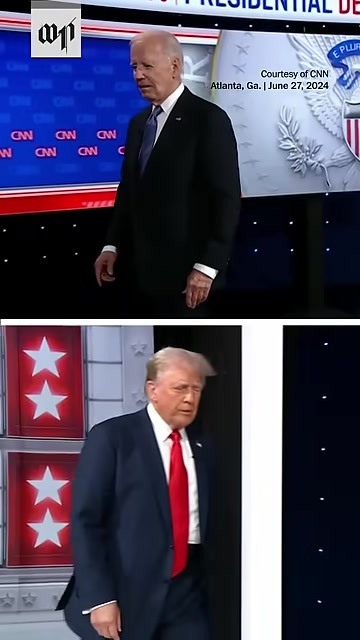
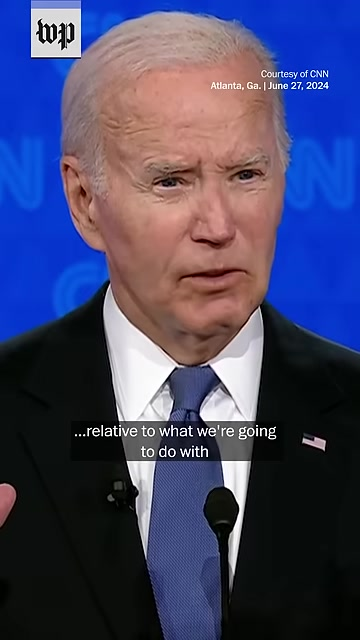
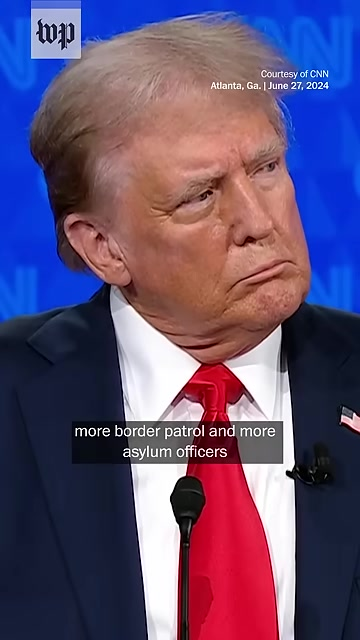
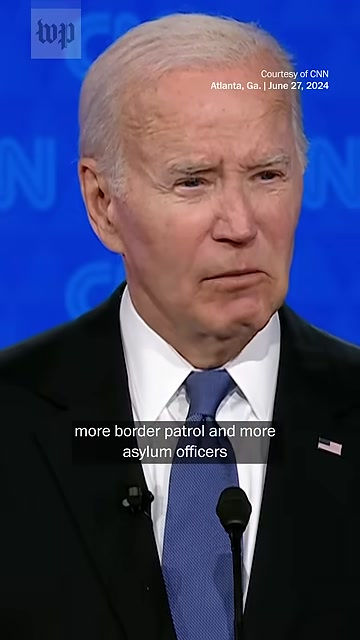
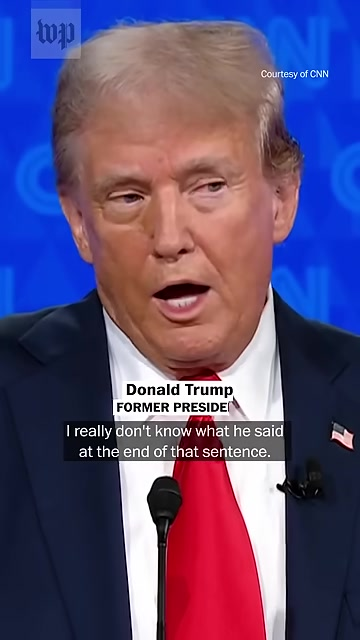
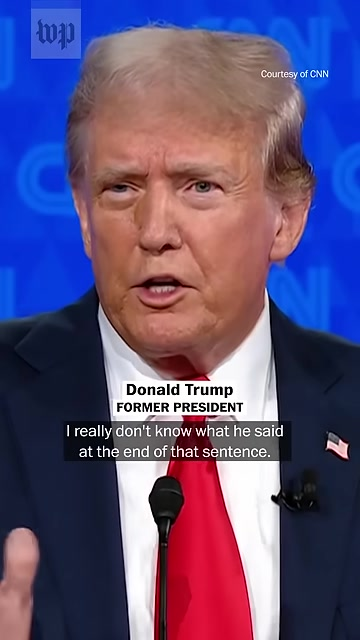
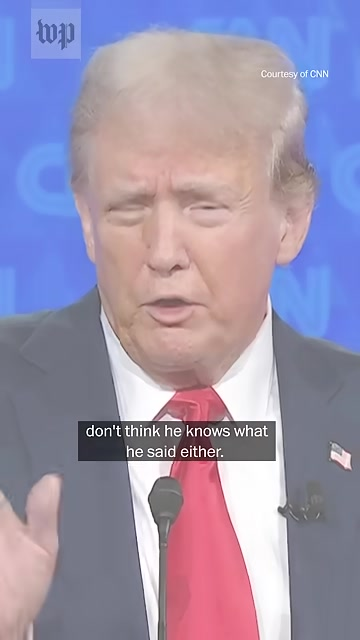
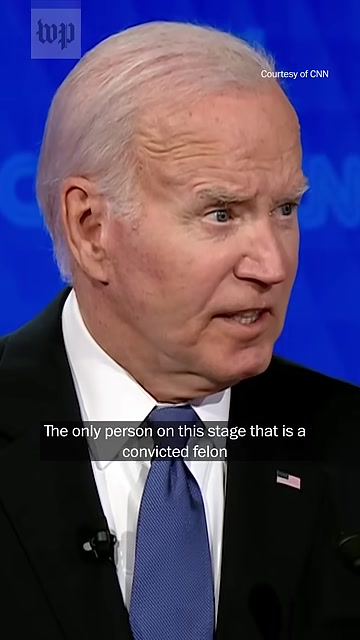
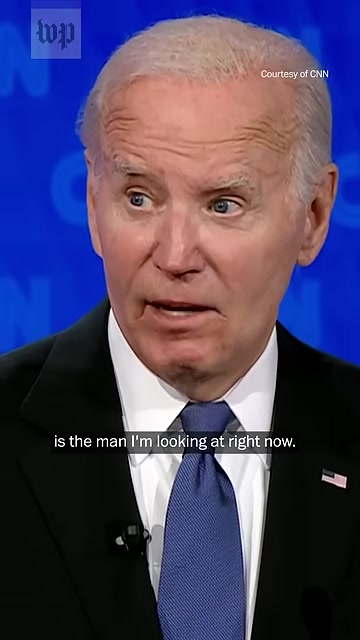
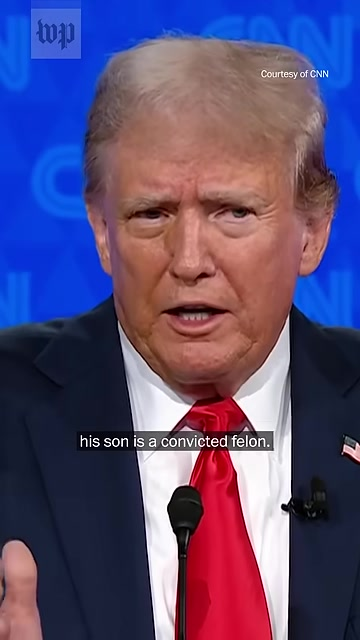
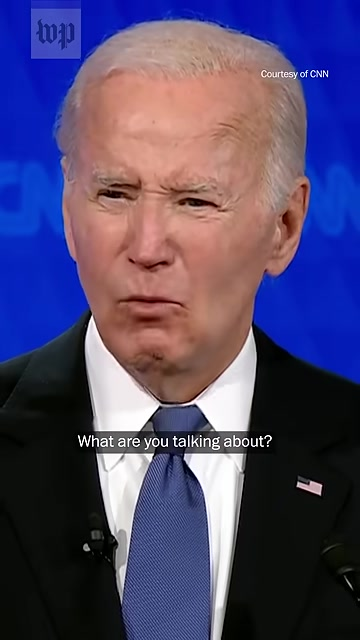
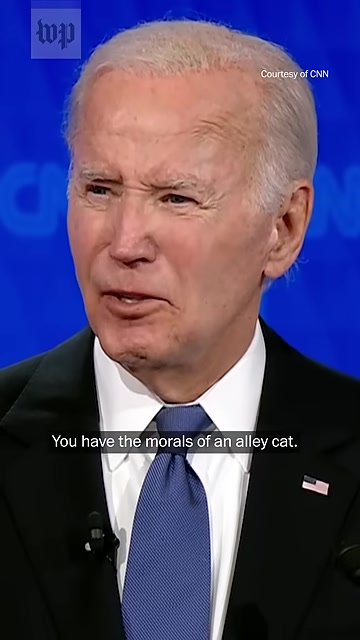
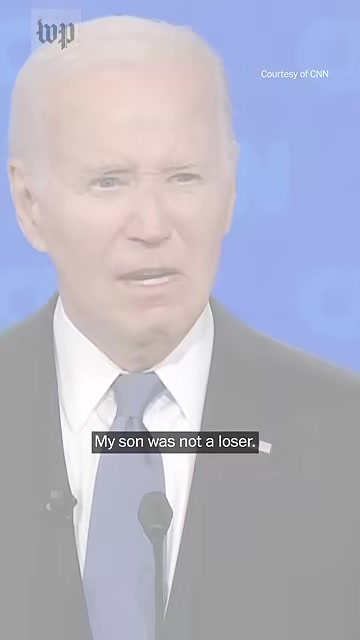
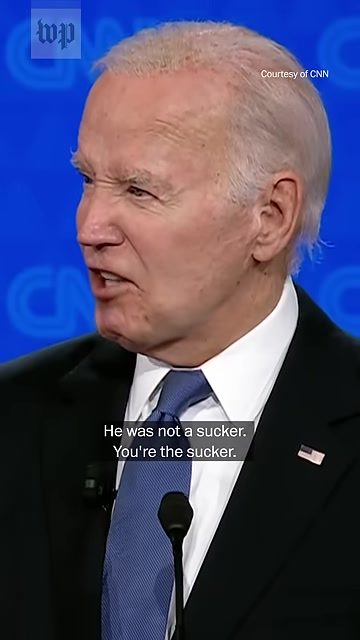
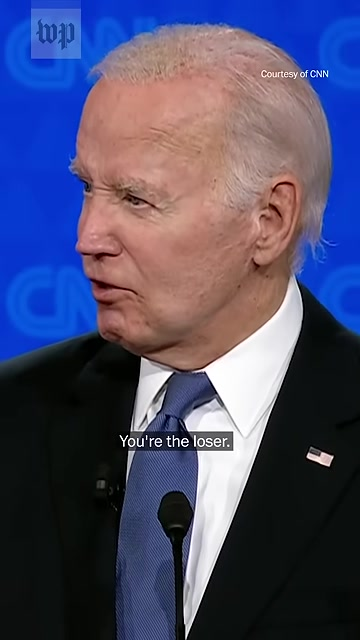

In [2]:
from IPython.display import HTML
import glob, base64
from pathlib import Path

files = sorted(glob.glob("data/debate/*.jpg"))
files = files[:15]
imgs = ""
for f in files:
    data = base64.b64encode(Path(f).read_bytes()).decode()
    mime = Path(f).suffix[1:].replace("jpg", "jpeg")
    imgs += f'<div style="text-align:center"><img src="data:image/{mime};base64,{data}" style="width:100%;border-radius:4px"><div style="font-size:.75em;color:#888">{Path(f).name}</div></div>'
HTML(f'<div style="display:grid;grid-template-columns:repeat(5,1fr);gap:8px">{imgs}</div>')


Even if the vibe answer was right, sometimes verification is more important than ease of use.

## What's this for?

These are the pipelines behind real investigations!

- [Documented examined hundreds of TikTok videos](https://pulitzercenter.org/misinformation-tiktok-how-documented-examined-hundreds-videos-different-languages): download, extract audio, transcribe with Whisper.
- [Público processed 7,616 TikTok health videos](https://www.publico.pt/interactivos/tiktok-desinformacao-saude-pernas-compridas) the same way, then used GPT-4o to extract verifiable claims from the transcripts.
- DW used a [custom detection model](https://universe.roboflow.com/menegat/brasileirao-pitch-ads) to [count betting ads in Brazilian football](https://www.dw.com/en/betting-ads-swamp-brazilian-football-as-addiction-spikes/a-72941493) broadcasts


**Up next:** Putting it all together — full pipelines and checking your work.
